In [15]:
# 'import' loads an external library so we can use its functions in this notebook.
# 'wrds'   connects Python to the WRDS financial database server.
# 'pandas' (nicknamed 'pd') is the main library for working with data tables.
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Replace the string below with your own WRDS account name (e.g. 'jsmith').
username = "jiatongli"

# wrds.Connection() opens a live connection to the WRDS database server.
# We store the connection object in 'db' so every later query can reuse it.
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [17]:
# SQL query to fetch daily stock data for AAPL (permno=14593) and MSFT (permno=10107)
# Source table: crsp.dsf (CRSP Daily Stock File)
# Time period: January 1, 2023 to January 1, 2025
sql_query = """
SELECT date, permno, prc, ret
FROM crsp.dsf
WHERE permno IN (14593, 10107)
AND date >= '2023-01-01' AND date <= '2025-01-01'
"""

# Execute the SQL query and load results into a pandas DataFrame
# 'date_cols' converts the 'date' column to datetime format
df = db.raw_sql(sql_query, date_cols=["date"])

# Close the database connection after data extraction (best practice)
db.close()
print("Data extraction complete. Connection closed.")

# Preview the first 5 rows of the dataset
print("\nFirst 5 rows of raw data:")
print(df.head())

Data extraction complete. Connection closed.

First 5 rows of raw data:
        date  permno        prc       ret
0 2023-01-03   10107     239.58 -0.001001
1 2023-01-04   10107  229.10001 -0.043743
2 2023-01-05   10107     222.31 -0.029638
3 2023-01-06   10107  224.92999  0.011785
4 2023-01-09   10107     227.12  0.009736


In [18]:
df = df.dropna(subset=["ret"])

# Convert negative prices to positive (CRSP uses negative prc for closing prices)
df["prc"] = df["prc"].abs()

# Split the dataset into separate DataFrames for AAPL and MSFT
aapl_data = df[df["permno"] == 14593].copy()
msft_data = df[df["permno"] == 10107].copy()

print("\nData cleaning completed.")
print(f"AAPL observations: {len(aapl_data)}")
print(f"MSFT observations: {len(msft_data)}")


Data cleaning completed.
AAPL observations: 502
MSFT observations: 502


In [10]:
print("\n=== AAPL Descriptive Statistics ===")
print(aapl_data[["prc", "ret"]].describe())

print("\n=== MSFT Descriptive Statistics ===")
print(msft_data[["prc", "ret"]].describe())

# Calculate annualized volatility (daily volatility * sqrt(252 trading days/year))
aapl_volatility = aapl_data["ret"].std() * np.sqrt(252)
msft_volatility = msft_data["ret"].std() * np.sqrt(252)

print(f"\n=== Annualized Volatility (2023-2025) ===")
print(f"AAPL: {aapl_volatility:.2%}")
print(f"MSFT: {msft_volatility:.2%}")
# ---------------------- Add these lines right below your current code ----------------------


# Calculate annualized return
aapl_annual_return = (aapl_data["ret"].mean() * 252)
msft_annual_return = (msft_data["ret"].mean() * 252)

print(f"\n=== Annualized Return (2023-2025) ===")
print(f"AAPL: {aapl_annual_return:.2%}")
print(f"MSFT: {msft_annual_return:.2%}")

# Calculate Sharpe Ratio (risk-free rate = 2%)
risk_free_rate = 0.02
aapl_sharpe = (aapl_annual_return - risk_free_rate) / aapl_volatility
msft_sharpe = (msft_annual_return - risk_free_rate) / msft_volatility

print(f"\n=== Sharpe Ratio ===")
print(f"AAPL: {aapl_sharpe:.2f}")
print(f"MSFT: {msft_sharpe:.2f}")

# Calculate Maximum Drawdown
aapl_mdd = (aapl_data["prc"] / aapl_data["prc"].cummax() - 1).min()
msft_mdd = (msft_data["prc"] / msft_data["prc"].cummax() - 1).min()

print(f"\n=== Maximum Drawdown ===")
print(f"AAPL: {aapl_mdd:.2%}")
print(f"MSFT: {msft_mdd:.2%}")


=== AAPL Descriptive Statistics ===
              prc       ret
count       502.0     502.0
mean   189.946474   0.00142
std      27.85704   0.01355
min        125.02 -0.048167
25%     172.07001 -0.006614
50%       185.205  0.001641
75%    214.277495  0.008951
max     259.01999  0.072649

=== MSFT Descriptive Statistics ===
              prc       ret
count       502.0     502.0
mean   367.343516  0.001258
std     61.855576  0.014271
min        222.31 -0.060528
25%     325.42501 -0.006803
50%    377.645005  0.001306
75%    418.672492  0.009735
max        467.56  0.072435

=== Annualized Volatility (2023-2025) ===
AAPL: 21.51%
MSFT: 22.66%

=== Annualized Return (2023-2025) ===
AAPL: 35.79%
MSFT: 31.70%

=== Sharpe Ratio ===
AAPL: 1.57
MSFT: 1.31

=== Maximum Drawdown ===
AAPL: -16.71%
MSFT: -15.49%


<Figure size 1400x600 with 0 Axes>

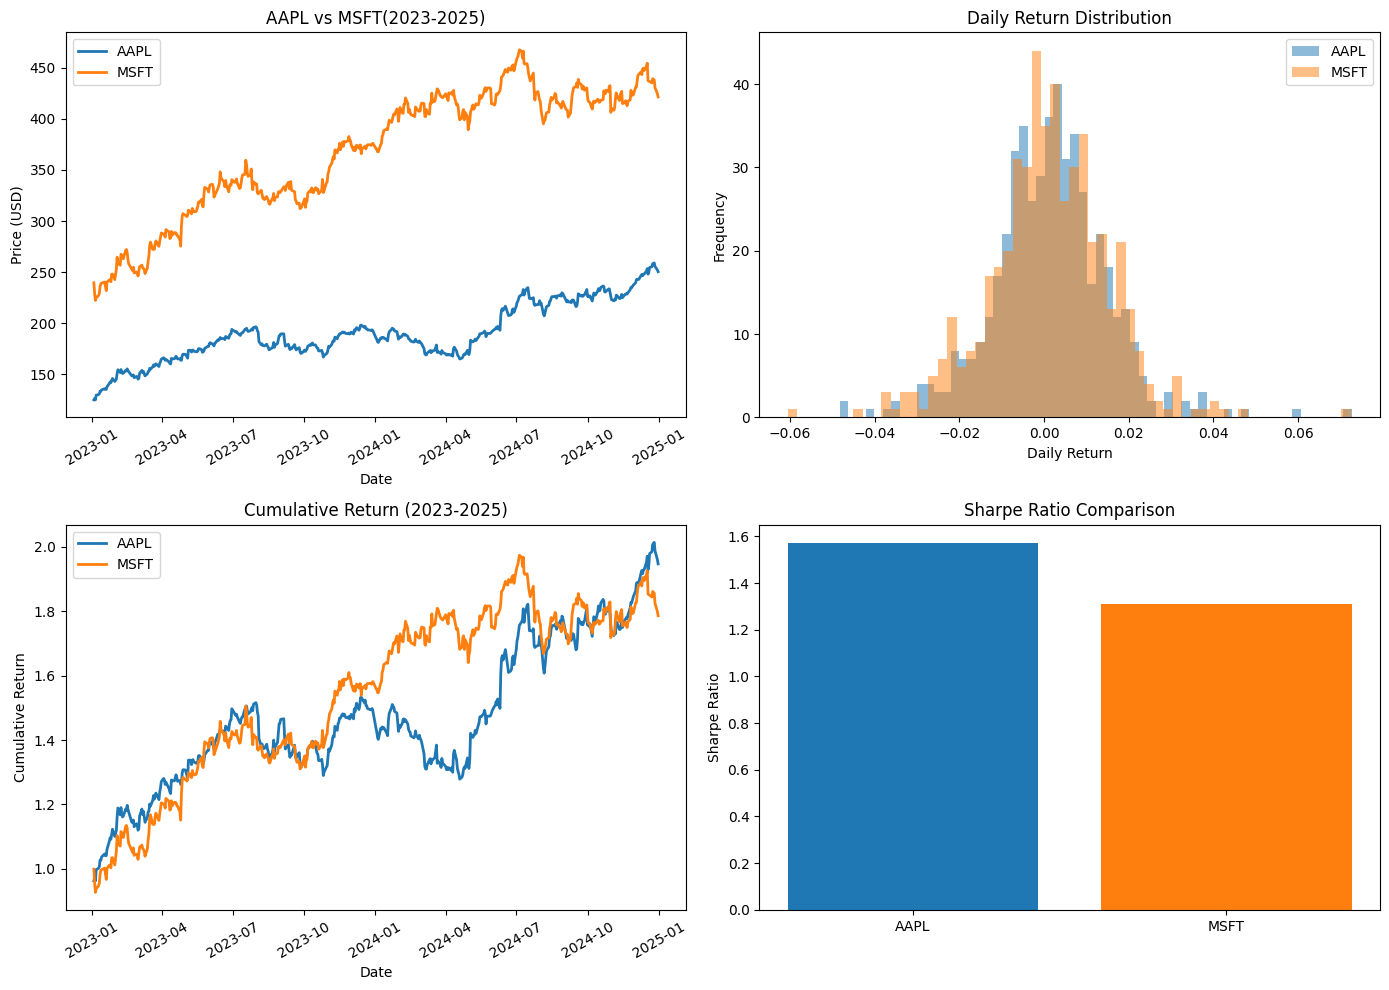


✅ Full visualization generated successfully!


In [12]:
# Calculate cumulative return for plotting
aapl_data["cum_ret"] = (1 + aapl_data["ret"]).cumprod()
msft_data["cum_ret"] = (1 + msft_data["ret"]).cumprod()
import matplotlib.pyplot as plt
# Set plot style for better readability
plt.style.use('default')
plt.figure(figsize=(14, 6))

# ---------------------- 6. Data Visualization (4 Plots, Full Version) ----------------------
plt.style.use('default')
plt.figure(figsize=(14, 10))

# Plot 1: Price Trend
plt.subplot(2,2,1)
plt.plot(aapl_data["date"], aapl_data["prc"], label="AAPL", color="#1f77b4", linewidth=2)
plt.plot(msft_data["date"], msft_data["prc"], label="MSFT", color="#ff7f0e", linewidth=2)
plt.title("AAPL vs MSFT(2023-2025)", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.xticks(rotation=30)

# Plot 2: Daily Return Distribution
plt.subplot(2,2,2)
plt.hist(aapl_data["ret"], bins=60, alpha=0.5, label="AAPL", color="#1f77b4")
plt.hist(msft_data["ret"], bins=60, alpha=0.5, label="MSFT", color="#ff7f0e")
plt.title("Daily Return Distribution", fontsize=12)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

# Plot 3: Cumulative Return
plt.subplot(2,2,3)
plt.plot(aapl_data["date"], aapl_data["cum_ret"], label="AAPL", color="#1f77b4", linewidth=2)
plt.plot(msft_data["date"], msft_data["cum_ret"], label="MSFT", color="#ff7f0e", linewidth=2)
plt.title("Cumulative Return (2023-2025)", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=30)

# Plot 4: Sharpe Ratio Bar Chart
plt.subplot(2,2,4)
labels = ["AAPL", "MSFT"]
sharpes = [aapl_sharpe, msft_sharpe]
plt.bar(labels, sharpes, color=["#1f77b4","#ff7f0e"])
plt.bar(labels, sharpes, color=["#1f77b4","#ff7f0e","#2ca02c"])
plt.title("Sharpe Ratio Comparison", fontsize=12)
plt.ylabel("Sharpe Ratio")

plt.tight_layout()
plt.show()
print("\n✅ Full visualization generated successfully!")
